In [6]:

from substructure_classifier.substructure_classifier_development import SubstructureClassifier
import json
example_config=SubstructureClassifier.get_example_classifier_config()
print(json.dumps(example_config, indent=4))

example_config["classifier_name"]="SimpleResnet2"

example_config["active_val_cats_live"]=[
    ["SIS_10e10_sub_val_extended", "NoNoiseDataset", {
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":True
    }

    ],
     ["SIS_10e9_sub_val_extended", "NoNoiseDataset", {
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":True
    }

    ]
]

example_config["NN_config"]={
        "num_classes":2
}


my_classifier = SubstructureClassifier("SimpleResnet2", config_dict=example_config)

{
    "classifier_name": "SimpleResnet5",
    "NN_model": "ResNet50",
    "NN_config": {
        "num_classes": 2
    },
    "active_val_cats_live": [
        [
            "SIS_10e10_sub_val_extended",
            "NoNoiseDataset",
            {
                "grid_width_arcsec": 6.0,
                "grid_pixel_side": 100,
                "broadcasting": true
            }
        ],
        [
            "SIS_10e9_sub_val_extended",
            "NoNoiseDataset",
            {
                "grid_width_arcsec": 6.0,
                "grid_pixel_side": 100,
                "broadcasting": true
            }
        ]
    ],
    "active_stage_id": null
}


In [4]:
from substructure_classifier.training_stage_multi import Stage
from substructure_classifier.substructure_classifier_development import SubstructureClassifier



example_config=Stage.get_example_config(return_config=True)
my_classifier=SubstructureClassifier("SimpleResnet1")

example_config["training_catalog"]="test2"
example_config["validation_like_train_catalog"]="test2"
example_config["dataset_class_str"]="NoNoiseDataset"
example_config["dataset_config"]={
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":False
}

example_config["samples_used_for_training"]=100
example_config["samples_used_for_validation"]=10
example_config["batch_size"]=2
example_config["jump_batch_val"]=5
example_config["learning_rate"]=0.001
example_config["epochs"]=2


import torch
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP

from deep_learning.NN_datasets import NoNoiseDataset
from deep_learning.NN_datasets.dataloaders import distributed_dataloader
from deep_learning.NN_models import ResNet50
import torch.nn.functional as F

def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = '127.0.0.1'
    os.environ['MASTER_PORT'] = '12355'
    # Switch to Gloo so we never invoke NCCL's P2P queries
    dist.init_process_group(
        backend='gloo',
        rank=rank,
        world_size=world_size
    )

    # Map each rank onto whichever GPU(s) you have
    n_gpus = torch.cuda.device_count()
    device_id = rank % n_gpus
    torch.cuda.set_device(device_id)
    print(f"[rank {rank}] running on cuda:{device_id}")
    return device_id

def cleanup():
    dist.destroy_process_group()

def single_proc(rank, world_size):
    gpu_id = setup(rank, world_size)

    my_stage=Stage(classifier_instance=my_classifier,gpu_id=gpu_id , config=example_config, device="cuda")
    my_stage.train(train_ready=True, early_stopping=False)()

    cleanup()

def main():
    world_size = 2
    mp.spawn(single_proc,
             args=(world_size,),
             nprocs=world_size,
             join=True)

if __name__ == "__main__":
    main()





Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/usr/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/usr/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'single_proc' on <module '__main__' (built-in)>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/usr/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/usr/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'single_proc' on <module '__main__' (built-in)>
W0726 14:23:43.238000 117849 torch/multiprocessing/spawn.py:169] Terminating process 117921 via signal SIGTERM


ProcessExitedException: process 0 terminated with exit code 1

In [4]:
from substructure_classifier.training_stage_development import Stage
from substructure_classifier.substructure_classifier_development import SubstructureClassifier



example_config=Stage.get_example_config(return_config=True)
my_classifier=SubstructureClassifier("SimpleResnet5")

example_config["training_catalog"]="SIS_10e10_sub_train"
example_config["validation_like_train_catalog"]="SIS_10e10_sub_val_extended"
example_config["dataset_class_str"]="NoNoiseDataset"
example_config["dataset_config"]={
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":False
}

example_config["samples_used_for_training"]=4000
example_config["samples_used_for_validation"]=1000
example_config["batch_size"]=128
example_config["jump_batch_val"]=7
example_config["learning_rate"]=0.001
example_config["epochs"]=2
my_stage=Stage(classifier_instance=my_classifier, config=example_config, device="cuda")

my_stage.train(train_ready=True, early_stopping=False)



example_config=Stage.get_example_config(return_config=True)

example_config["training_catalog"]="SIS_10e10_sub_train"
example_config["validation_like_train_catalog"]="SIS_10e10_sub_val_extended"
example_config["dataset_class_str"]="NoNoiseDataset"
example_config["dataset_config"]={
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":False
}

example_config["samples_used_for_training"]=4000
example_config["samples_used_for_validation"]=1000
example_config["batch_size"]=128
example_config["jump_batch_val"]=7
example_config["learning_rate"]=0.0002
example_config["epochs"]=2
my_stage=Stage(classifier_instance=my_classifier, config=example_config, device="cuda")

my_stage.train(train_ready=True, early_stopping=False)



example_config=Stage.get_example_config(return_config=True)

example_config["training_catalog"]="SIS_10e9_sub_train"
example_config["validation_like_train_catalog"]="SIS_10e9_sub_val_extended"
example_config["dataset_class_str"]="NoNoiseDataset"
example_config["dataset_config"]={
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":False
}

example_config["samples_used_for_training"]=4000
example_config["samples_used_for_validation"]=1000
example_config["batch_size"]=128
example_config["jump_batch_val"]=7
example_config["learning_rate"]=0.00005
example_config["epochs"]=2
my_stage=Stage(classifier_instance=my_classifier, config=example_config, device="cuda")

my_stage.train(train_ready=True, early_stopping=False)




example_config=Stage.get_example_config(return_config=True)

example_config["training_catalog"]="SIS_10e8_sub_train"
example_config["validation_like_train_catalog"]="SIS_10e8_sub_val_extended"
example_config["dataset_class_str"]="NoNoiseDataset"
example_config["dataset_config"]={
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":False
}

example_config["samples_used_for_training"]=4000
example_config["samples_used_for_validation"]=1000
example_config["batch_size"]=128
example_config["jump_batch_val"]=7
example_config["learning_rate"]=0.00001
example_config["epochs"]=2
my_stage=Stage(classifier_instance=my_classifier, config=example_config, device="cuda")

my_stage.train(train_ready=True, early_stopping=False)



example_config=Stage.get_example_config(return_config=True)

example_config["training_catalog"]="big_conor_similar_training_cat"
example_config["validation_like_train_catalog"]="big_conor_similar_training_cat_val"
example_config["dataset_class_str"]="NoNoiseDataset"
example_config["dataset_config"]={
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":False
}

example_config["samples_used_for_training"]=10000
example_config["samples_used_for_validation"]=1000
example_config["batch_size"]=128
example_config["jump_batch_val"]=7
example_config["learning_rate"]=0.000001
example_config["epochs"]=1
my_stage=Stage(classifier_instance=my_classifier, config=example_config, device="cuda")

my_stage.train(train_ready=True, early_stopping=False)


forcing only one entry per catalog in add activ val cat live, substructure classifier dev
should have updated the classifier config file
forcing only one entry per catalog in add activ val cat live, substructure classifier dev
Catalog SIS_10e10_sub_val_extended already exists in active validation catalogs.
should have updated the classifier config file
Implement the device compatibility check in _check_ready_to_train, util.py
Using device: cuda
Currently this dataloader is calculating the images in float32
curretly this dataloader implementing a random crop of the image as well as a rotation.
Model initialized with default random parameters
Using device: cuda
Currently this dataloader is calculating the images in float32
curretly this dataloader implementing a random crop of the image as well as a rotation.
Using device: cuda
Currently this dataloader is calculating the images in float32
curretly this dataloader implementing a random crop of the image as well as a rotation.
Using devic

Epoch 1/2:   0%|          | 0/32 [00:00<?, ?batch/s]

New best validation loss: 0.694682


Epoch 2/2:   0%|          | 0/32 [00:00<?, ?batch/s]

Model parameters saved to /raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/b7c0b49ebeda7a6fad663585778d9a1521ad7eaa826f1d0d5984d7b736006426/trained_params.pth
should have updated the classifier config file
Implement the device compatibility check in _check_ready_to_train, util.py
Live metrics saved.
Loading paramters of the current stage, not the parent. This mode is intended for using an already trained stage for some evaluations
Training completed metrics saved to /raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/b7c0b49ebeda7a6fad663585778d9a1521ad7eaa826f1d0d5984d7b736006426/training_completed_metrics.json
forcing only one entry per catalog in add activ val cat live, substructure classifier dev
Catalog SIS_10e10_sub_train already exists in active validation catalogs.
should have updated the classifier config file
forcing only one entry per catalog in add activ val cat live, substructure classifier dev
Catalog SIS_10e10_sub_

...

Epoch 2/2:   0%|          | 0/32 [00:00<?, ?batch/s]

New best validation loss: 0.689813
Model parameters saved to /raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/eb461d713149ca4107542da27a80f8f789acb10907a8831f38d37230f4fabb5e/trained_params.pth
should have updated the classifier config file
Implement the device compatibility check in _check_ready_to_train, util.py
Live metrics saved.
Loading paramters of the current stage, not the parent. This mode is intended for using an already trained stage for some evaluations
Training completed metrics saved to /raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/eb461d713149ca4107542da27a80f8f789acb10907a8831f38d37230f4fabb5e/training_completed_metrics.json
forcing only one entry per catalog in add activ val cat live, substructure classifier dev
should have updated the classifier config file
forcing only one entry per catalog in add activ val cat live, substructure classifier dev
should have updated the classifier config file
Implement the 

Epoch 1/1:   0%|          | 0/79 [00:00<?, ?batch/s]

New best validation loss: 0.961408
New best validation loss: 0.857017
New best validation loss: 0.771349
New best validation loss: 0.738814
New best validation loss: 0.722287
New best validation loss: 0.705303
New best validation loss: 0.692453
New best validation loss: 0.688724
New best validation loss: 0.684052
New best validation loss: 0.679157
Final model is best with loss 0.676556
Model parameters saved to /raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/a0c9fd24b799e602b5e45bea82f0f0686a55a776d0d4a41034df1158bc71e2e9/trained_params.pth
should have updated the classifier config file
Implement the device compatibility check in _check_ready_to_train, util.py
Live metrics saved.
Loading paramters of the current stage, not the parent. This mode is intended for using an already trained stage for some evaluations
Training completed metrics saved to /raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/a0c9fd24b799e602b5e45bea82f0f06

TrainingCompletedMetrics(accuracy={}, f1_score={}, precision={}, recall={})

In [12]:
example_config=Stage.get_example_config(return_config=True)

example_config["training_catalog"]="big_conor_similar_training_cat"
example_config["validation_like_train_catalog"]="big_conor_similar_training_cat_val"
example_config["dataset_class_str"]="NoNoiseDataset"
example_config["dataset_config"]={
        "grid_width_arcsec":6.0,
        "grid_pixel_side":100,
        "broadcasting":True
}

example_config["samples_used_for_training"]=50000
example_config["samples_used_for_validation"]=1000
example_config["batch_size"]=1024
example_config["jump_batch_val"]=10
example_config["learning_rate"]=0.000001
example_config["epochs"]=1
my_stage=Stage(classifier_instance=my_classifier, config=example_config, device="cuda")

my_stage.train(train_ready=True, early_stopping=False)

forcing only one entry per catalog in add activ val cat live, substructure classifier dev
Catalog big_conor_similar_training_cat already exists in active validation catalogs.
should have updated the classifier config file
forcing only one entry per catalog in add activ val cat live, substructure classifier dev
Catalog big_conor_similar_training_cat_val already exists in active validation catalogs.
should have updated the classifier config file
Implement the device compatibility check in _check_ready_to_train, util.py
Using device: cuda
Currently this dataloader is calculating the images in float32
curretly this dataloader implementing a random crop of the image as well as a rotation.
[DEBUG] parent_stage_id = '4c13b467d68e468dcc095de133f1abe4b8d681aa2c7f1c613ecad98e104a3f2c'
[DEBUG] loading checkpoint from '/raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/4c13b467d68e468dcc095de133f1abe4b8d681aa2c7f1c613ecad98e104a3f2c/trained_params.pth'
[DEBUG] before lo

Epoch 1/1:   0%|          | 0/49 [00:00<?, ?batch/s]

New best validation loss: 0.668720
New best validation loss: 0.667525
Model parameters saved to /raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/0048891579c9d390ec2efde1fe2597b19fa6db6939e45e6306d87f507ce7e377/trained_params.pth
should have updated the classifier config file
Implement the device compatibility check in _check_ready_to_train, util.py
Live metrics saved.
Loading paramters of the current stage, not the parent. This mode is intended for using an already trained stage for some evaluations
Training completed metrics saved to /raven/u/fcitterio/master_thesis_code/trained_classifiers/SimpleResnet5/stages/0048891579c9d390ec2efde1fe2597b19fa6db6939e45e6306d87f507ce7e377/training_completed_metrics.json


TrainingCompletedMetrics(accuracy={}, f1_score={}, precision={}, recall={})

Right now considering only selection by catalog and not by dataset in plotting in substructure_classifier_development.py
running loss plot for the training catalogs


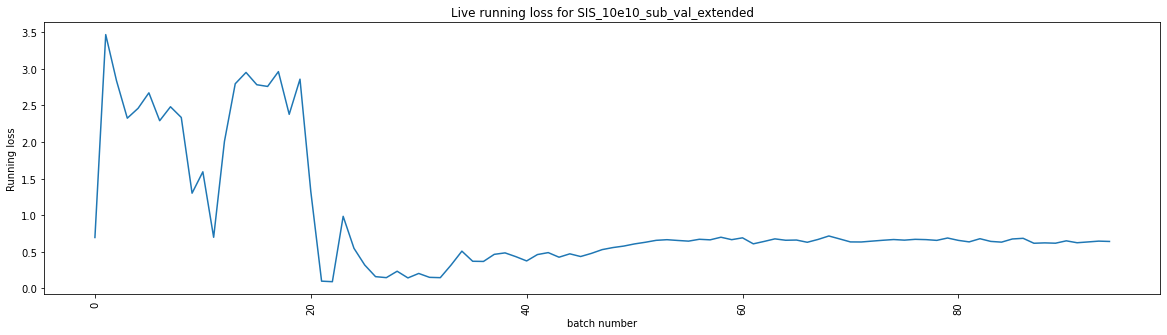

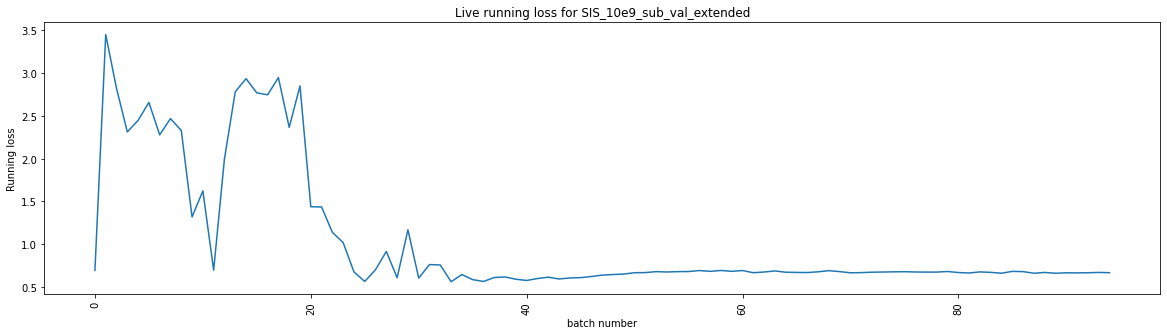

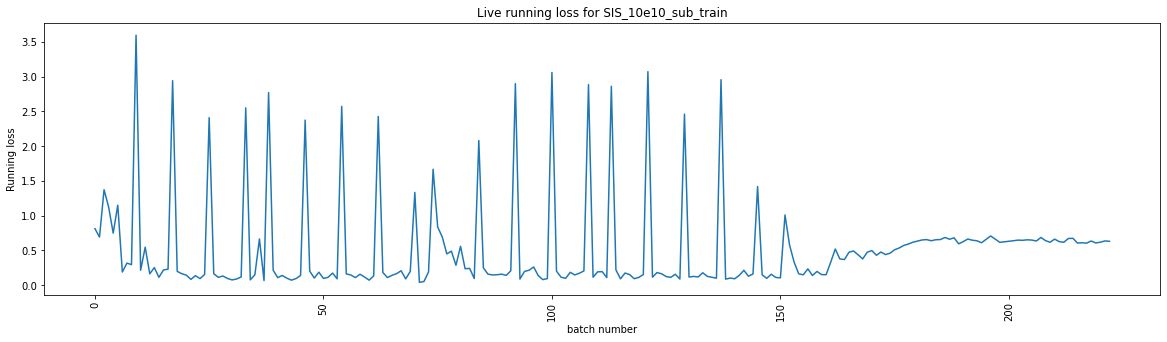

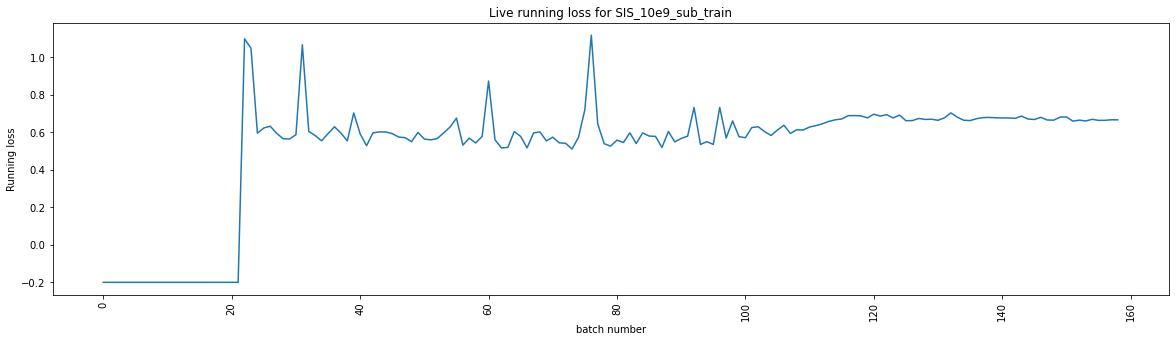

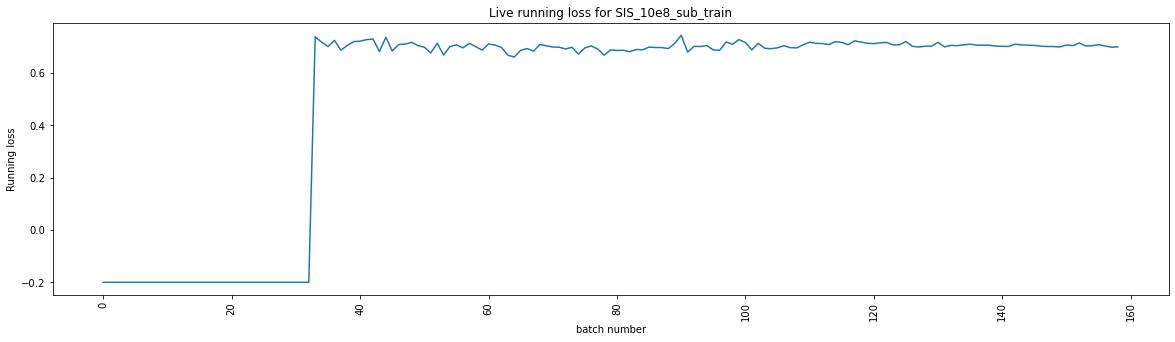

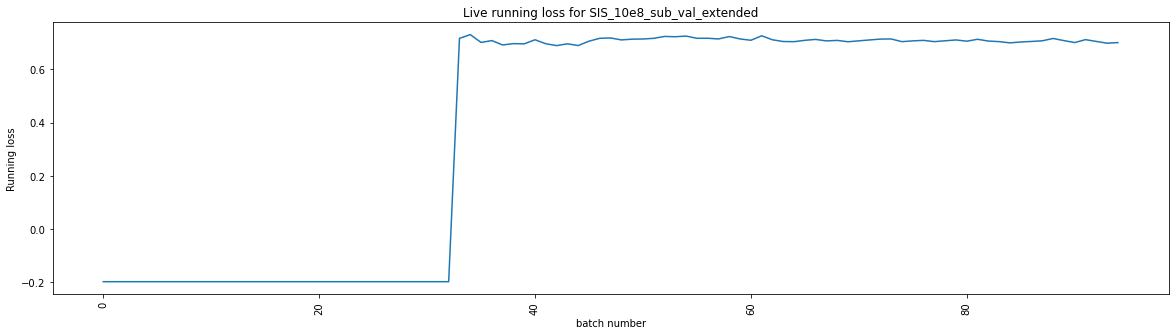

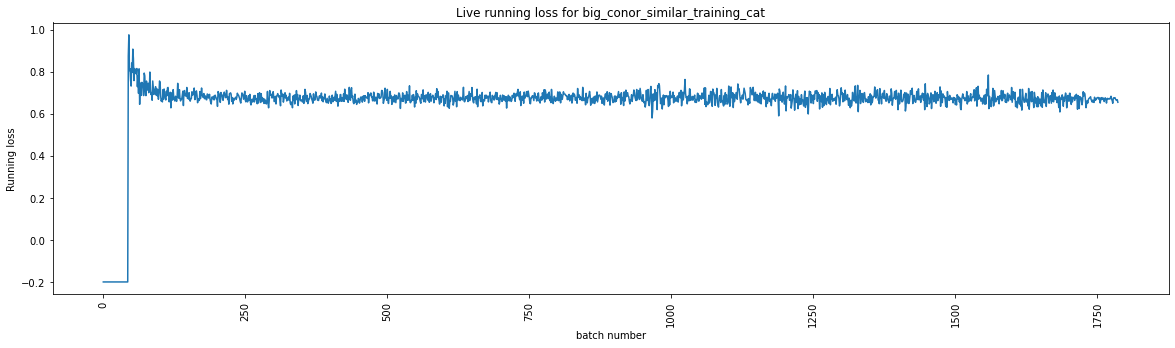

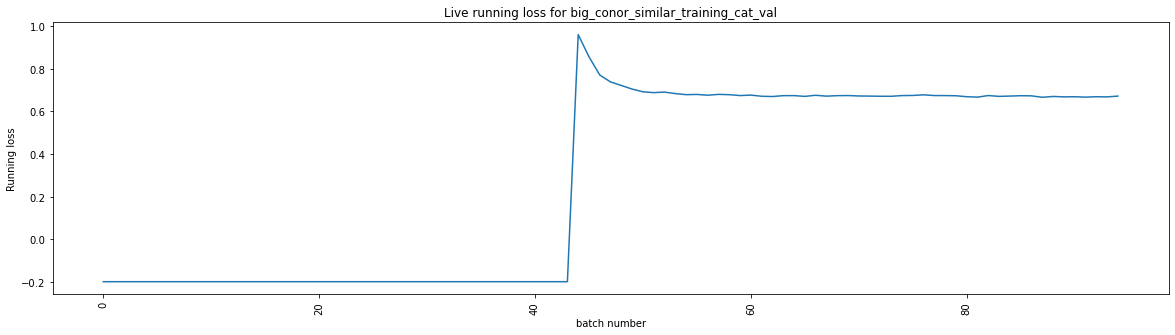

hard coded shown metrics at _plot_concatedated_data in substructure_classifier_development.py


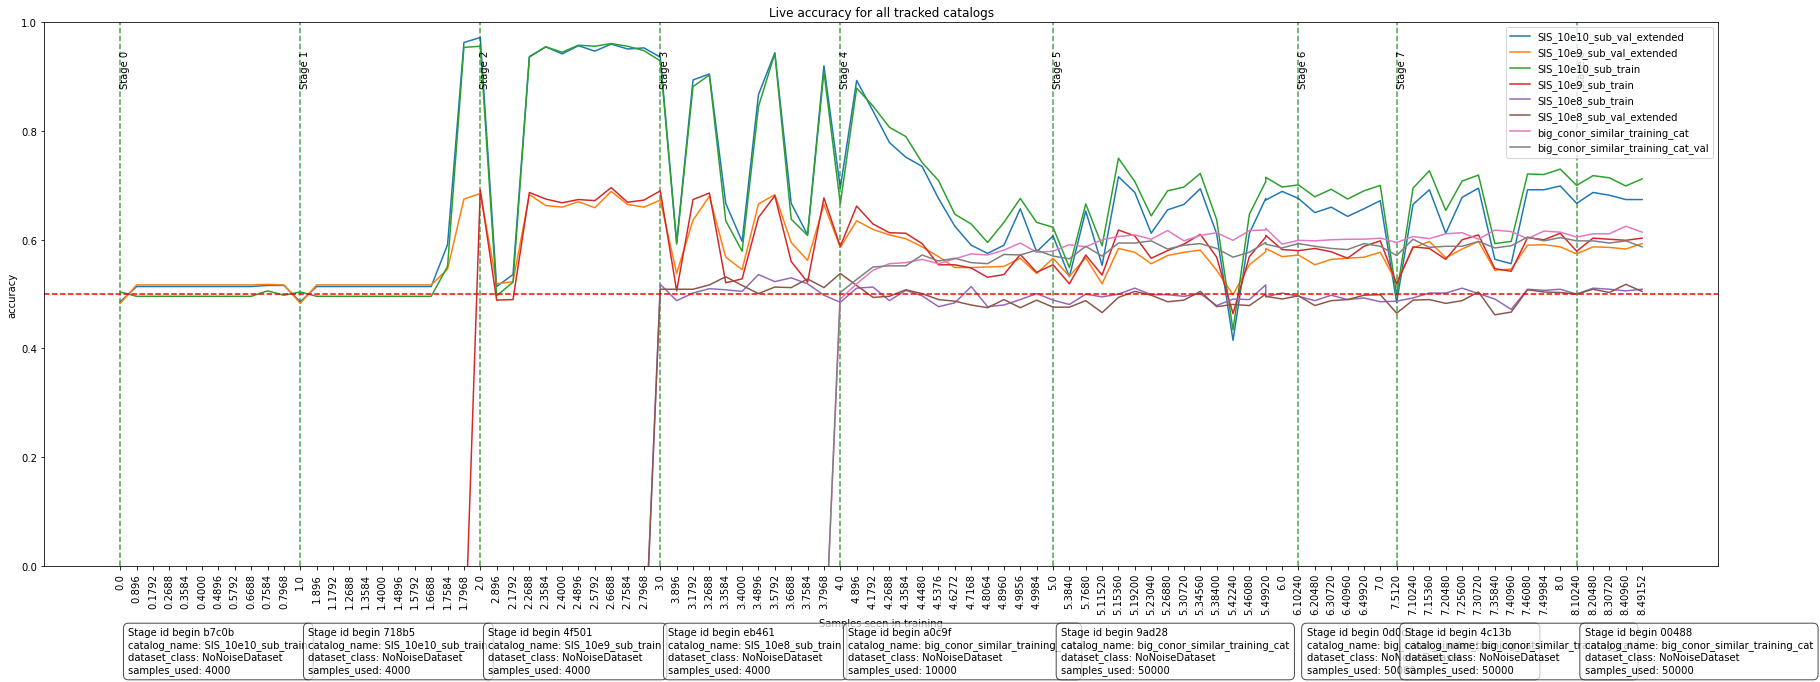

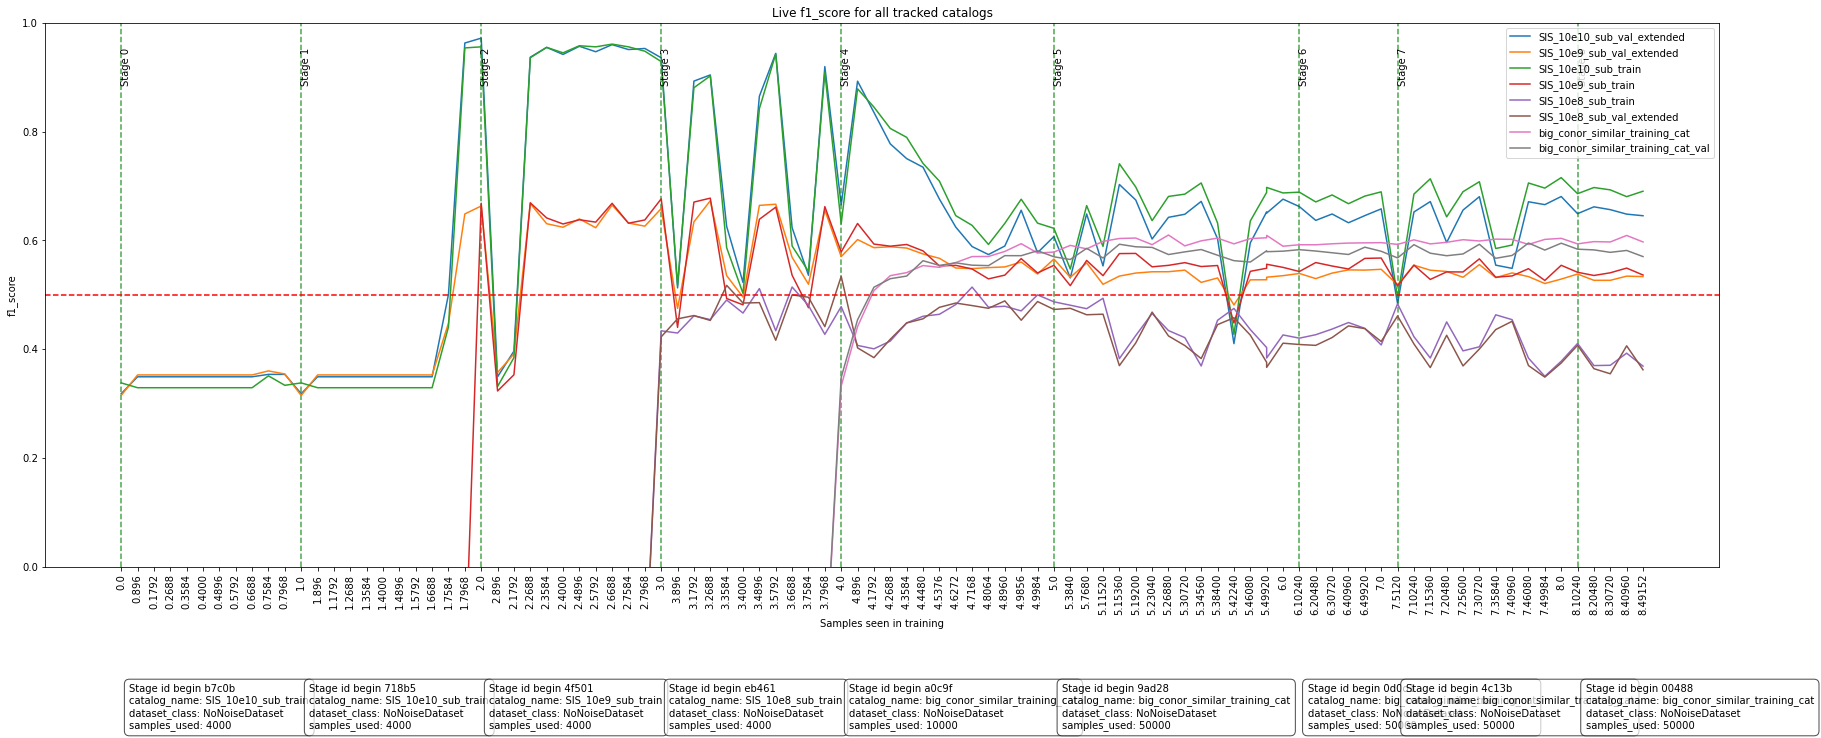

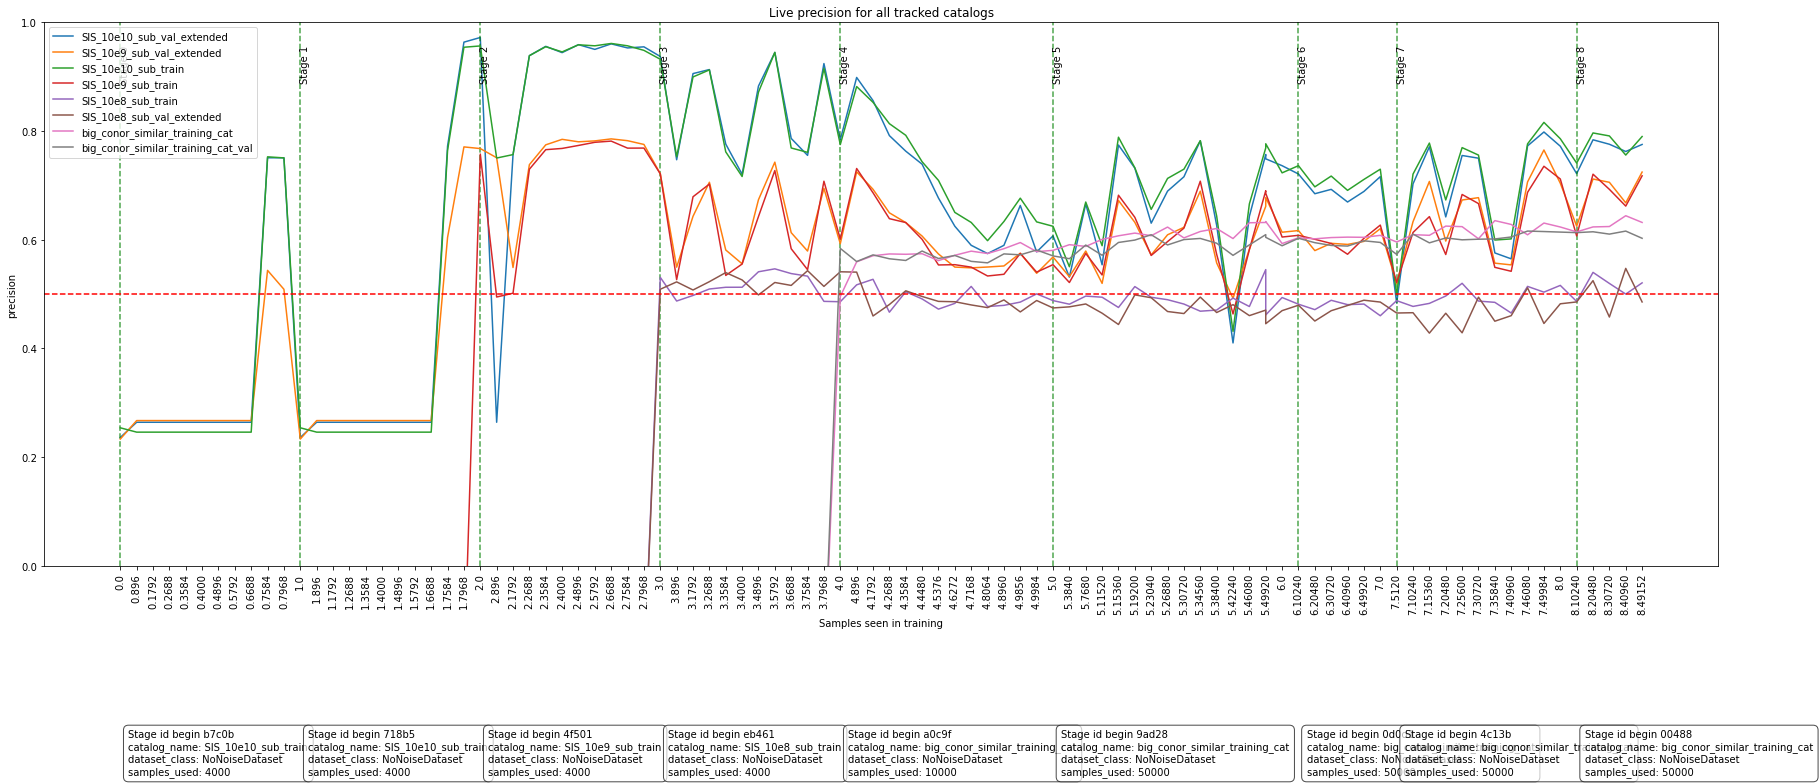

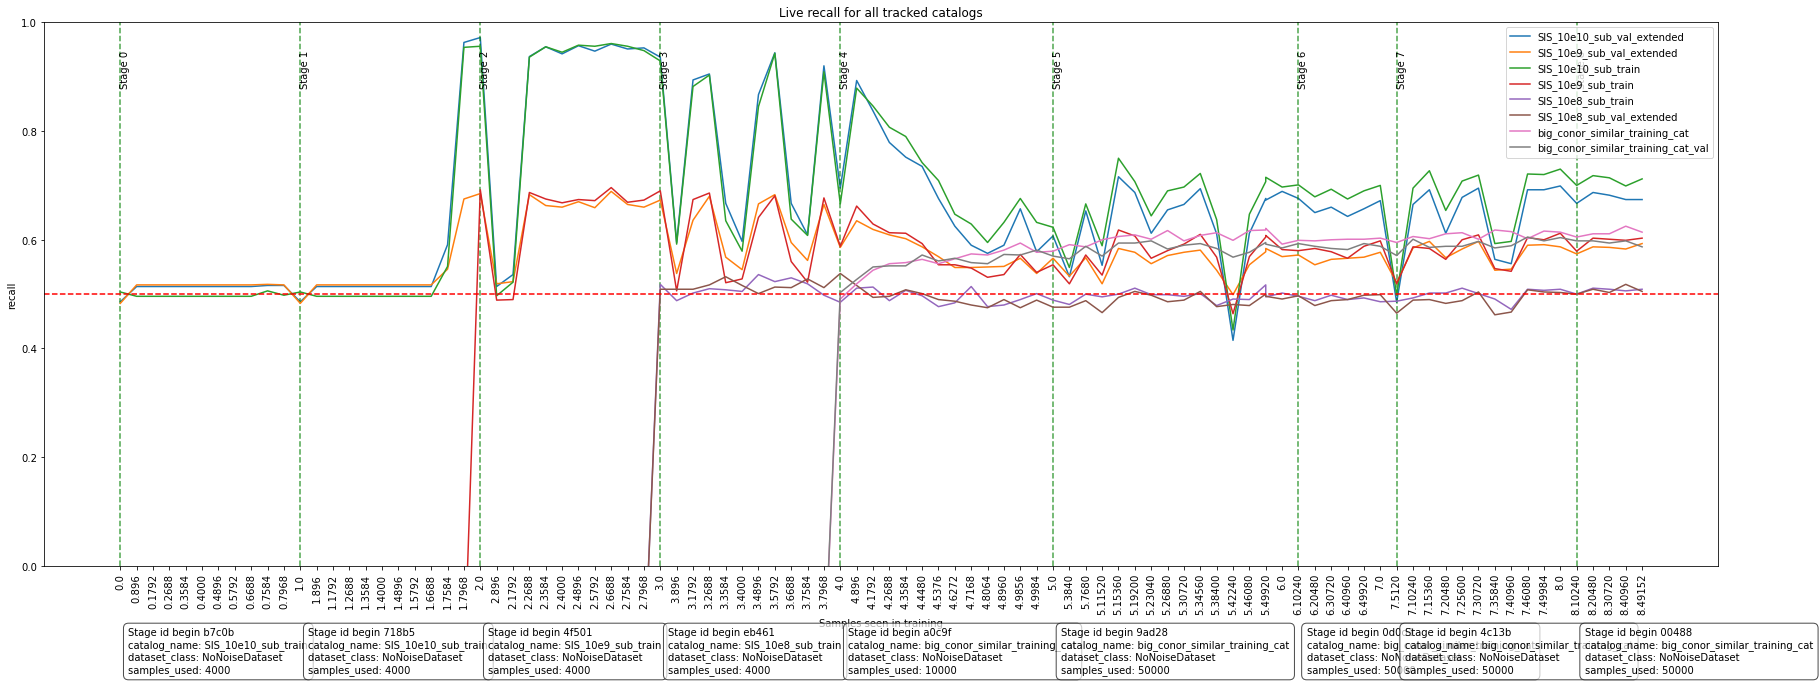

In [13]:
from substructure_classifier.substructure_classifier_development import SubstructureClassifier

my_classifier=SubstructureClassifier(classifier_name="SimpleResnet5")
my_classifier._plot_concatenated_data()

Right now considering only selection by catalog and not by dataset in plotting in substructure_classifier_development.py
running loss plot for the training catalogs


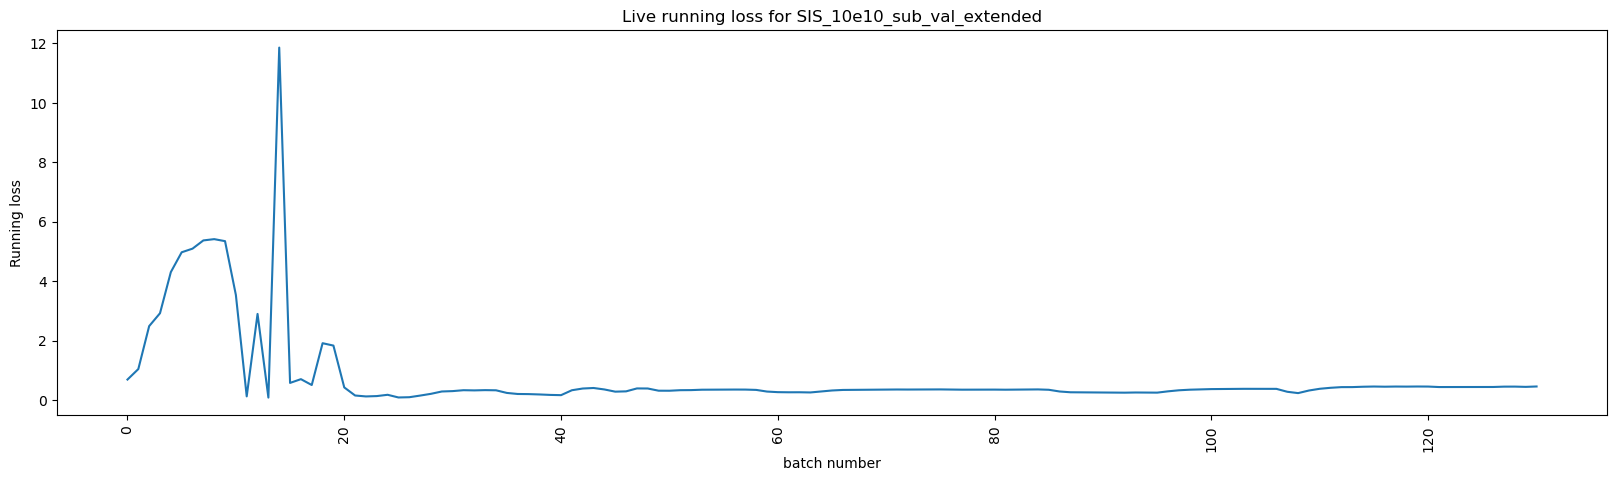

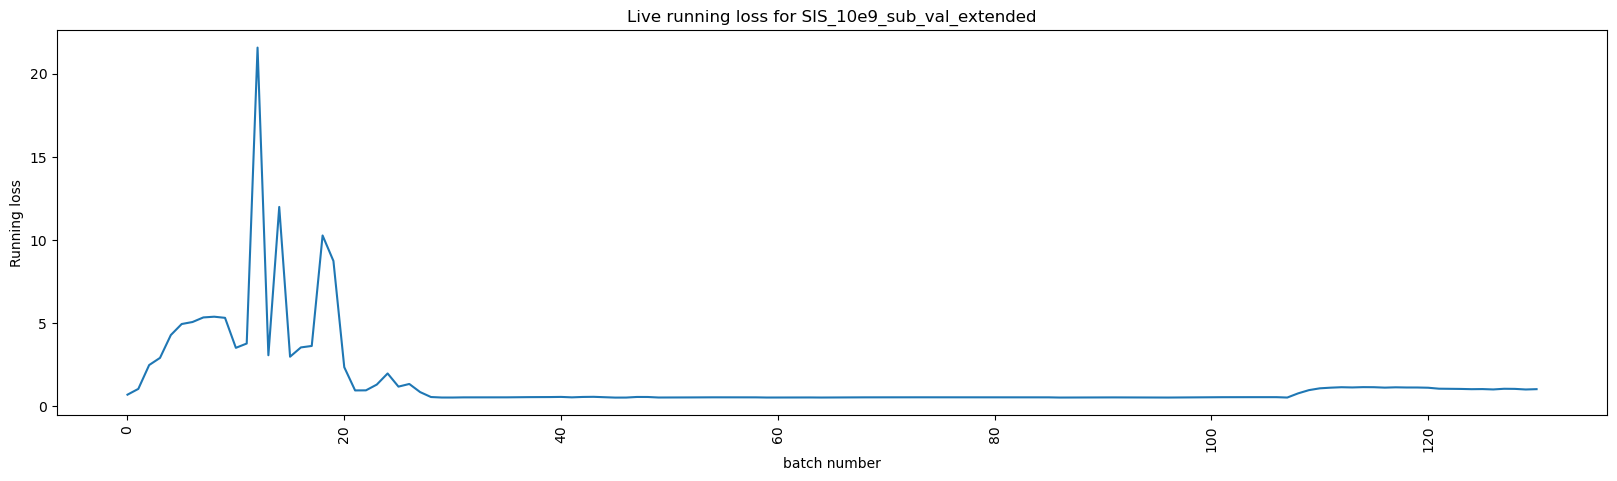

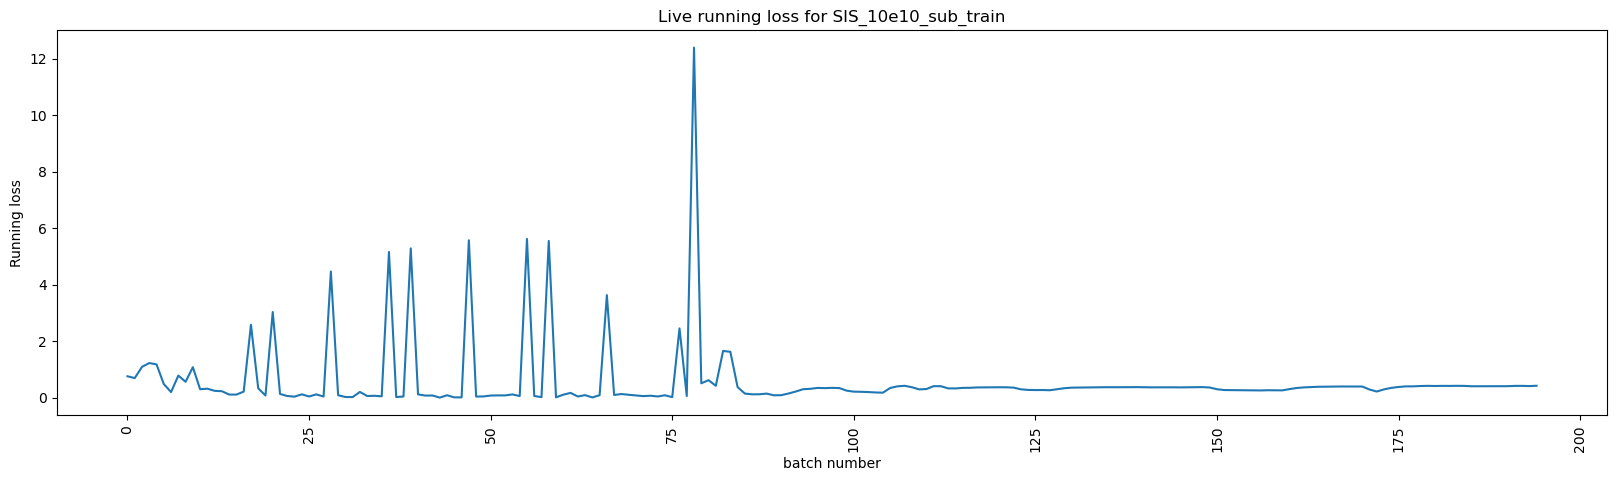

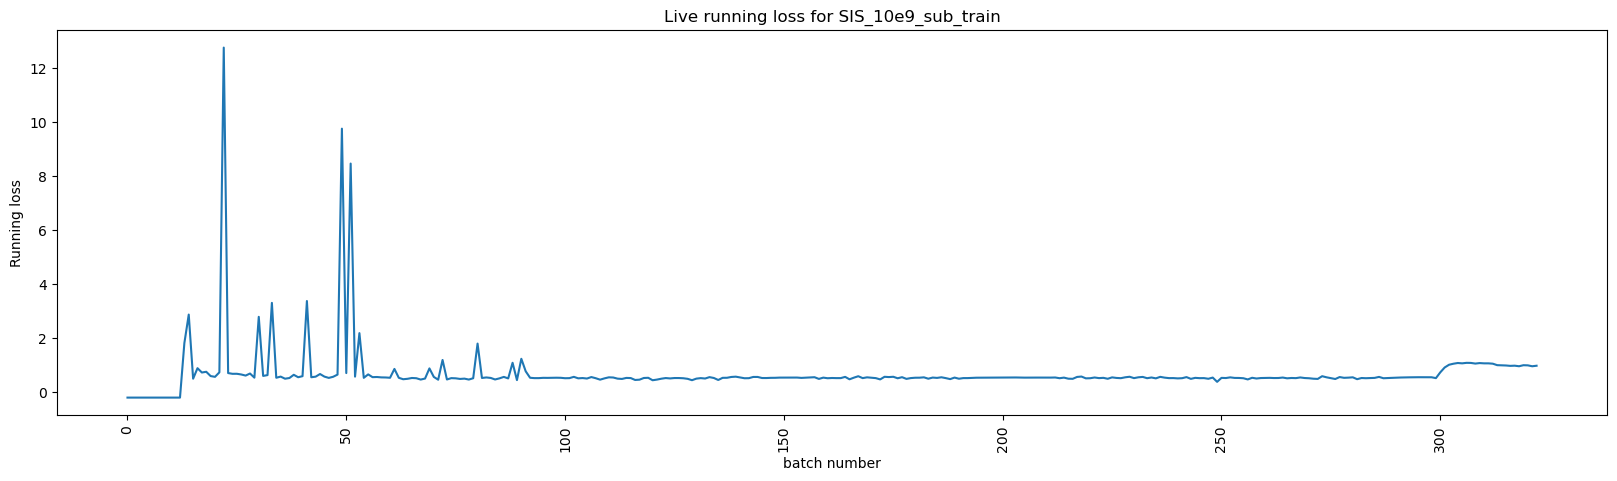

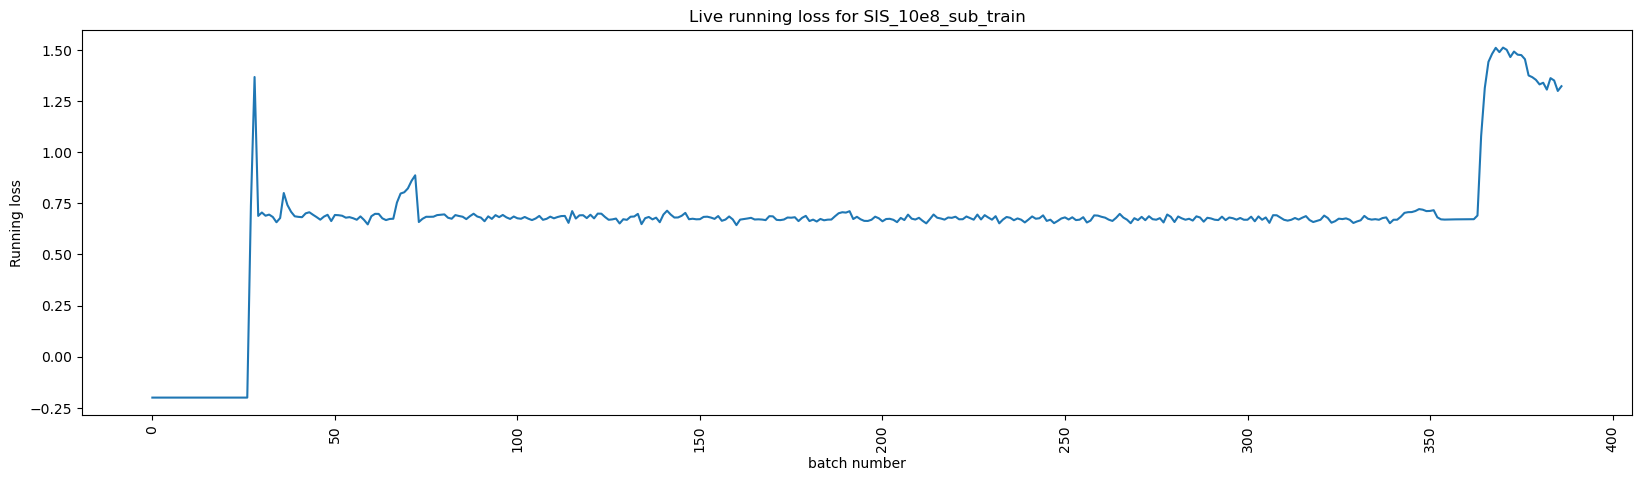

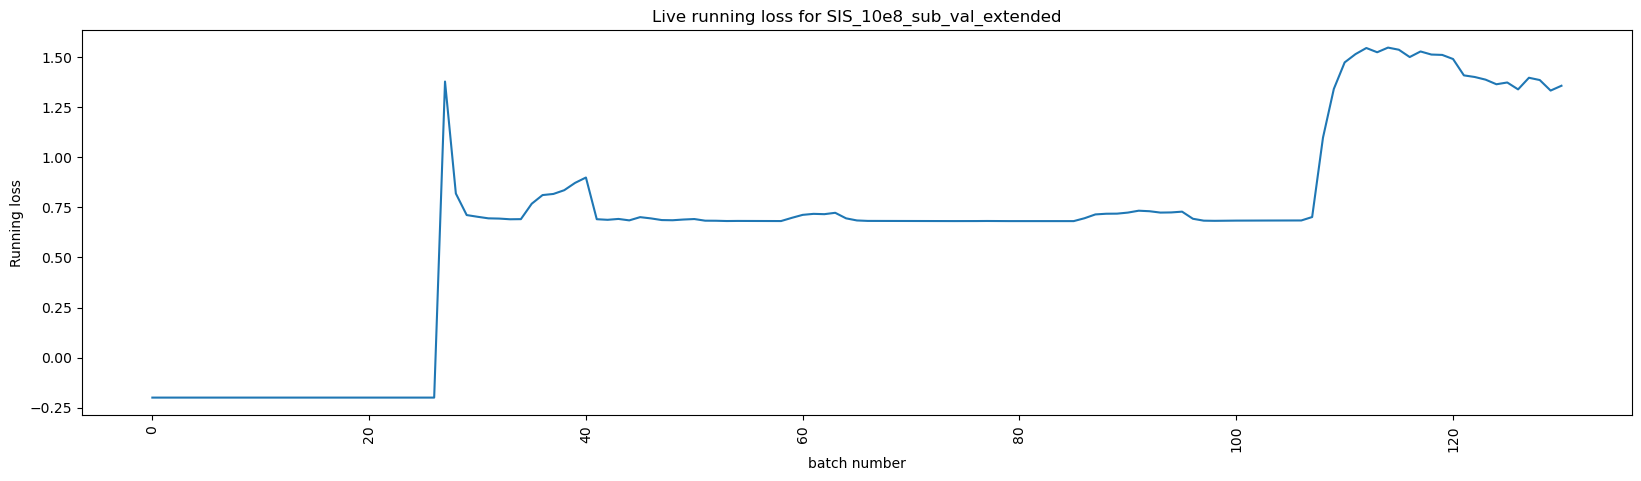

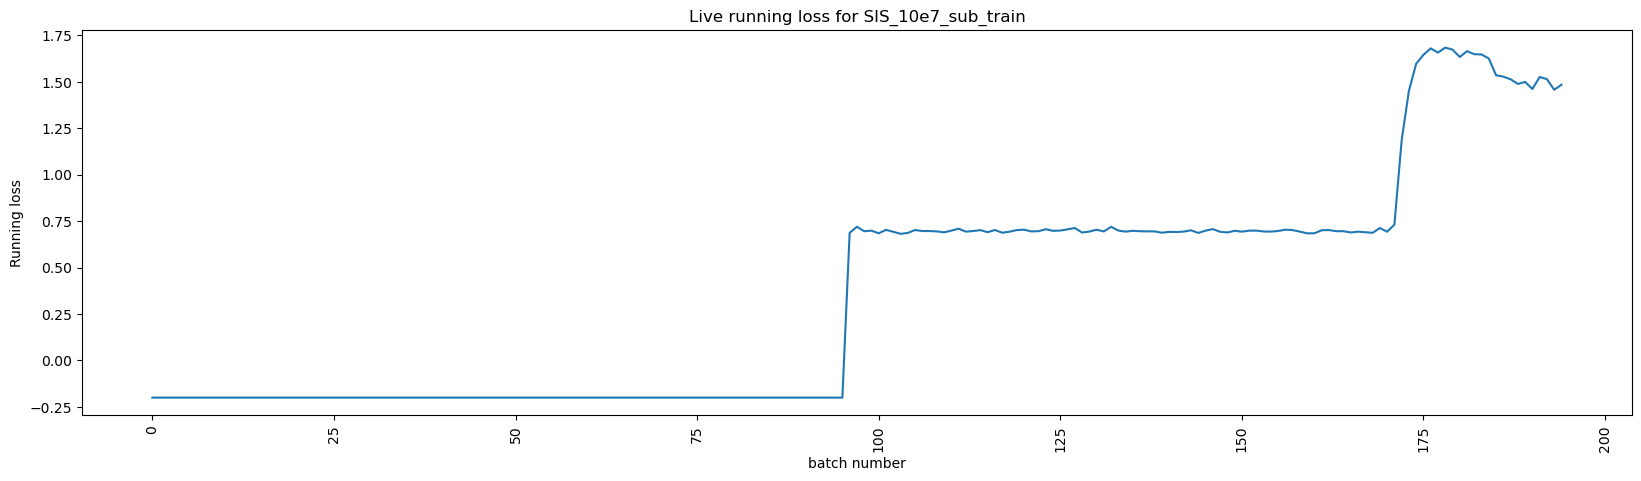

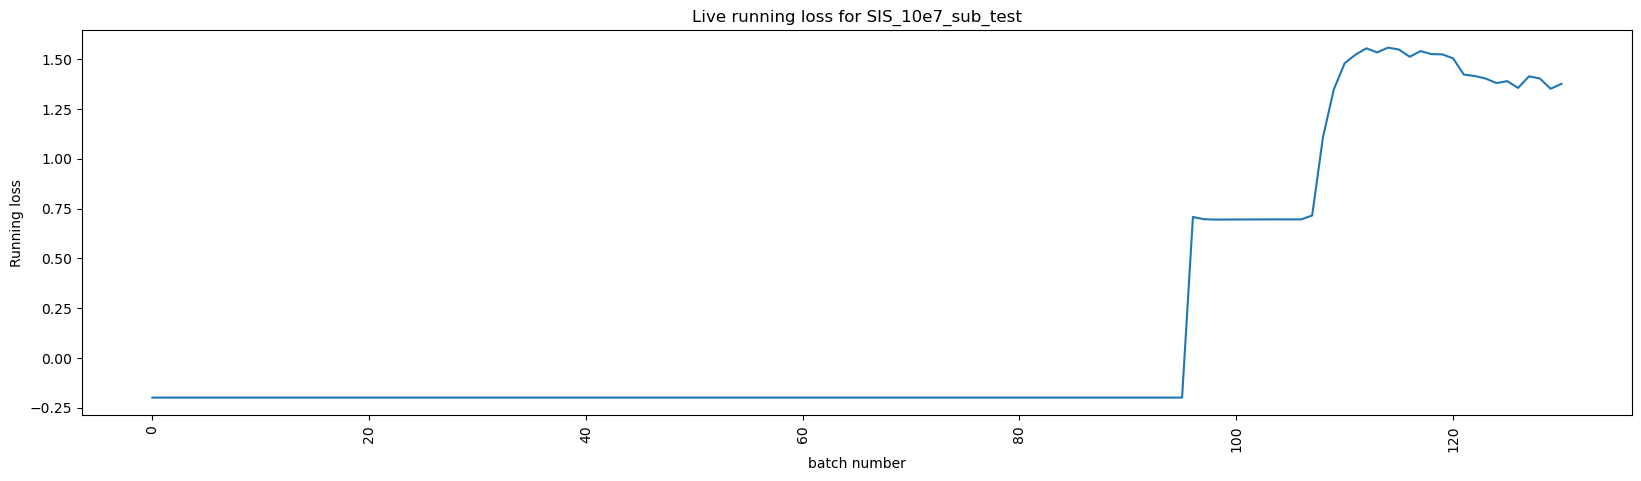

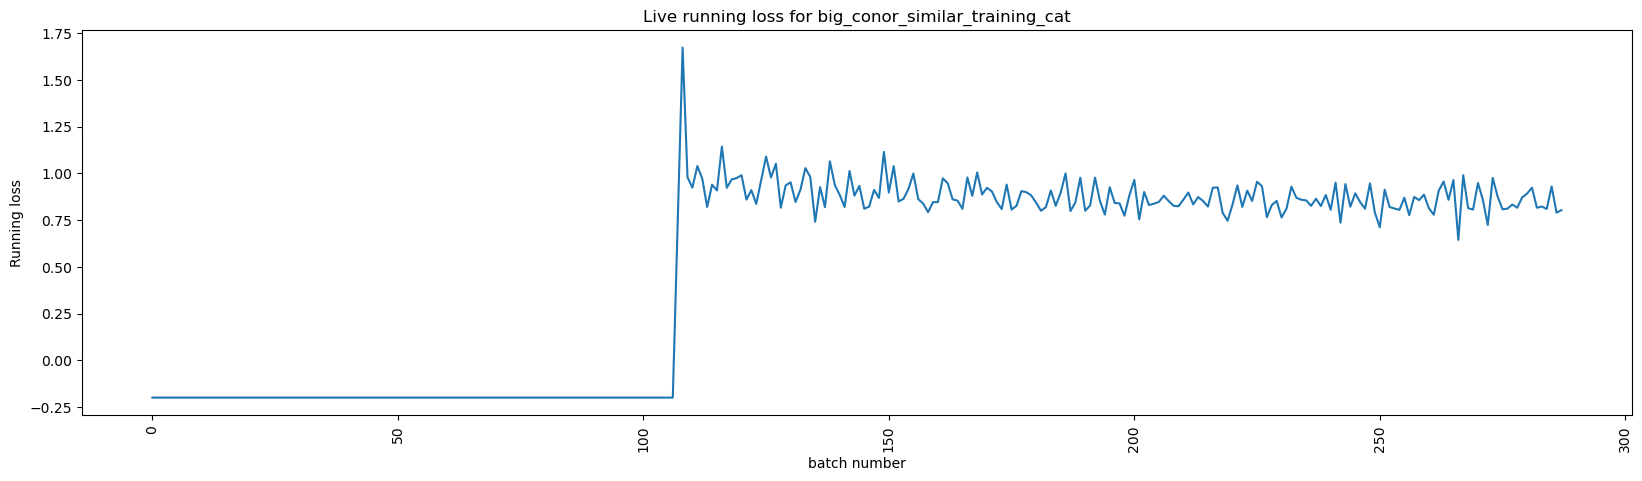

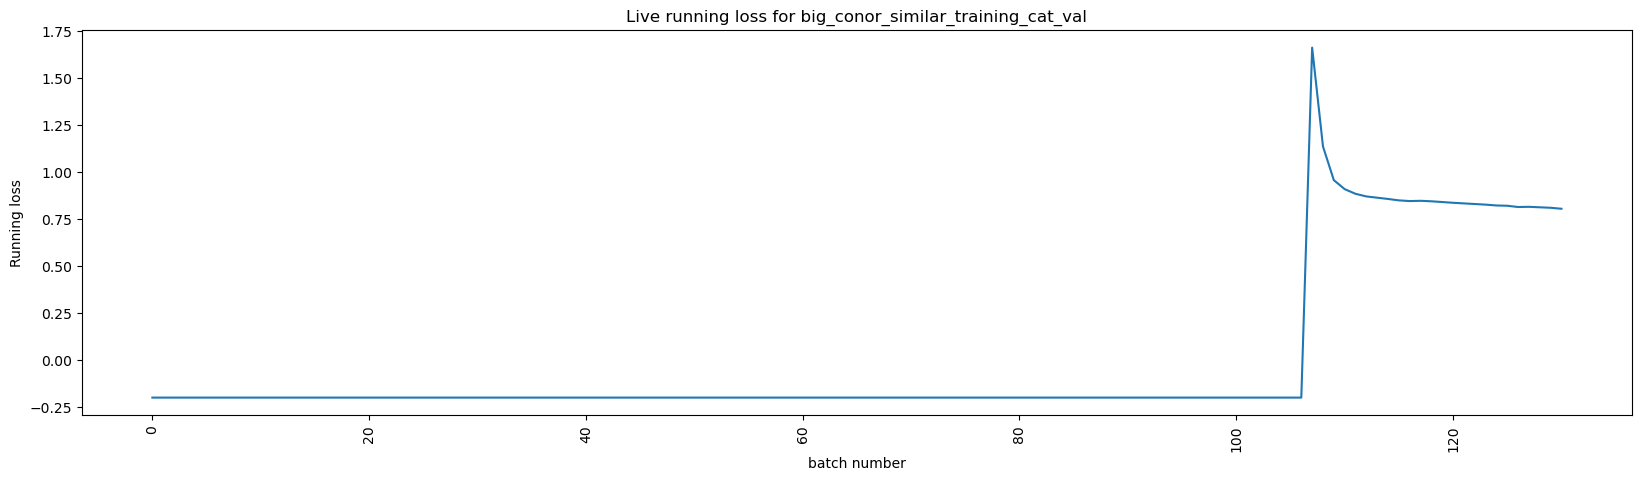

hard coded shown metrics at _plot_concatedated_data in substructure_classifier_development.py


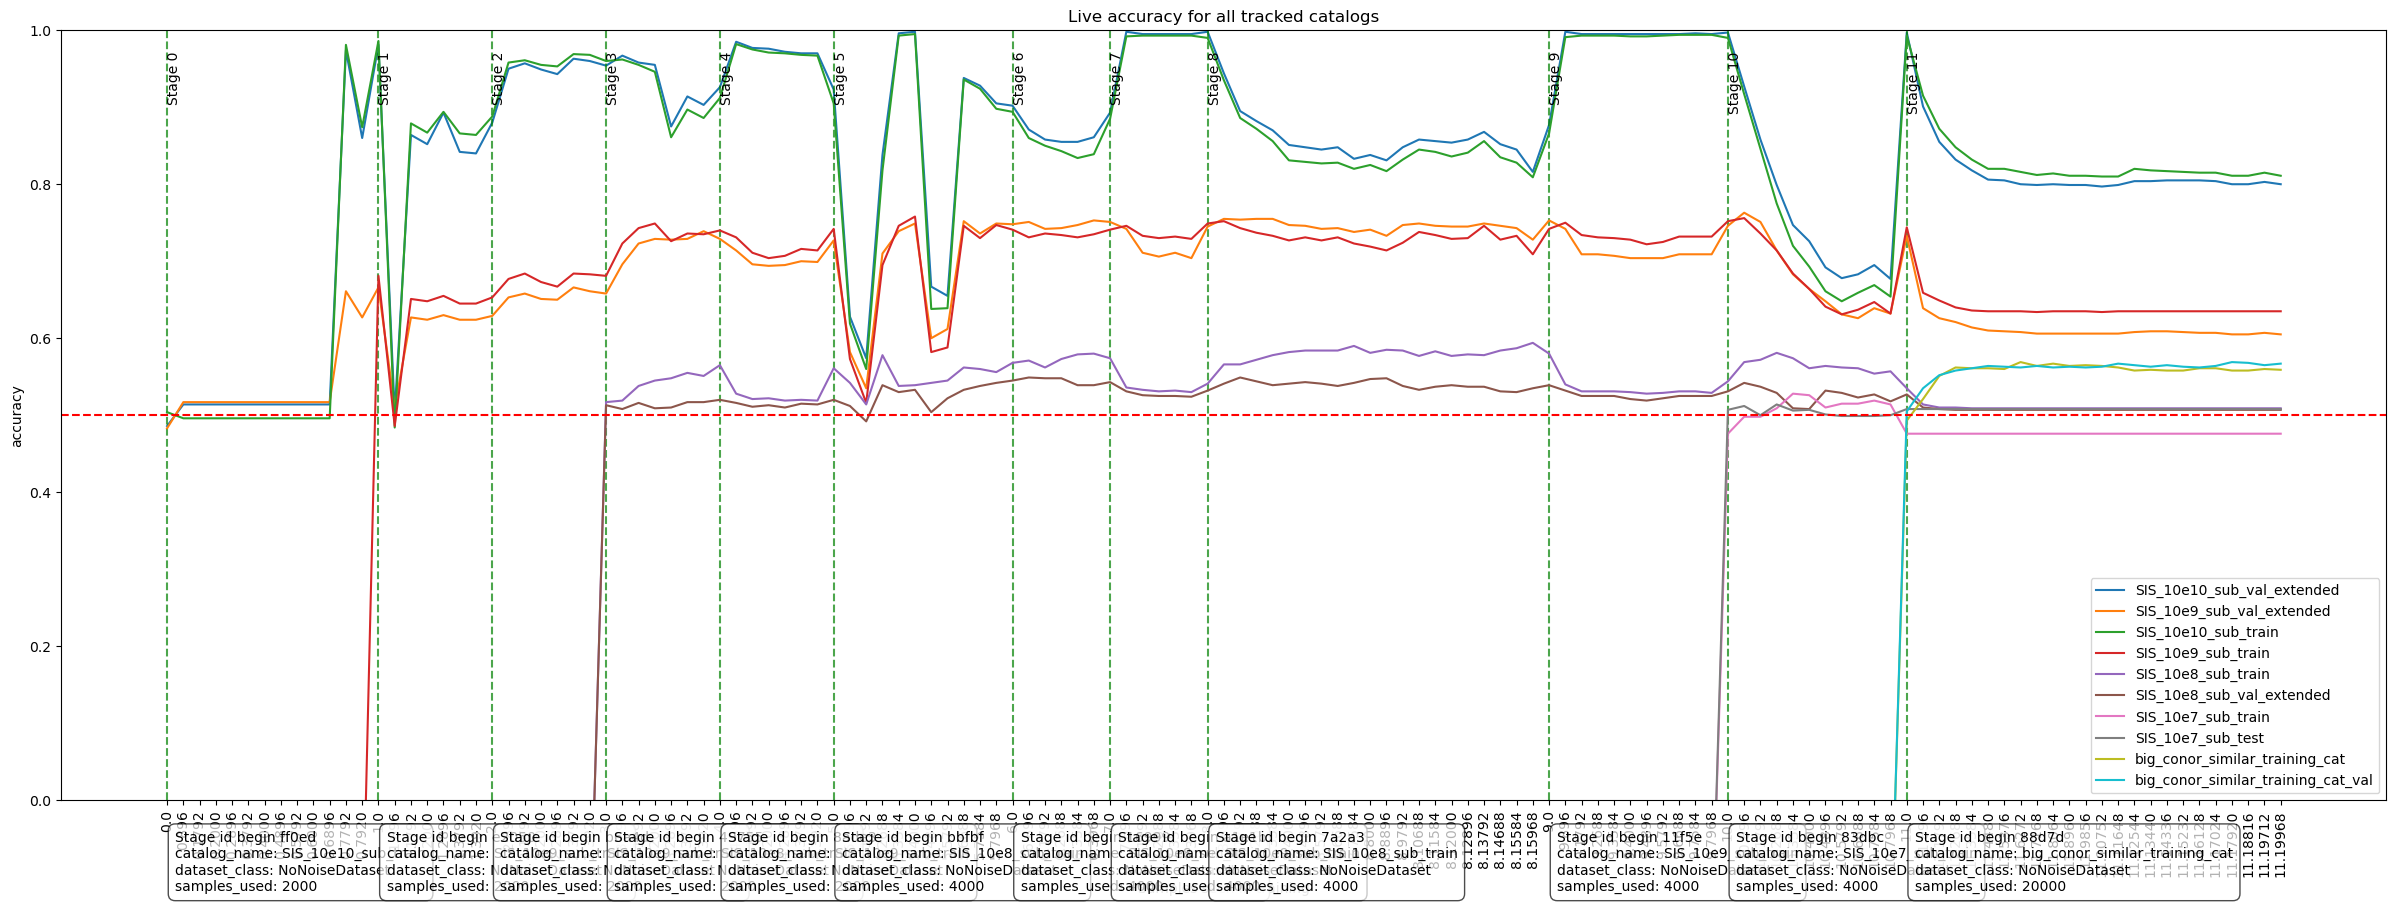

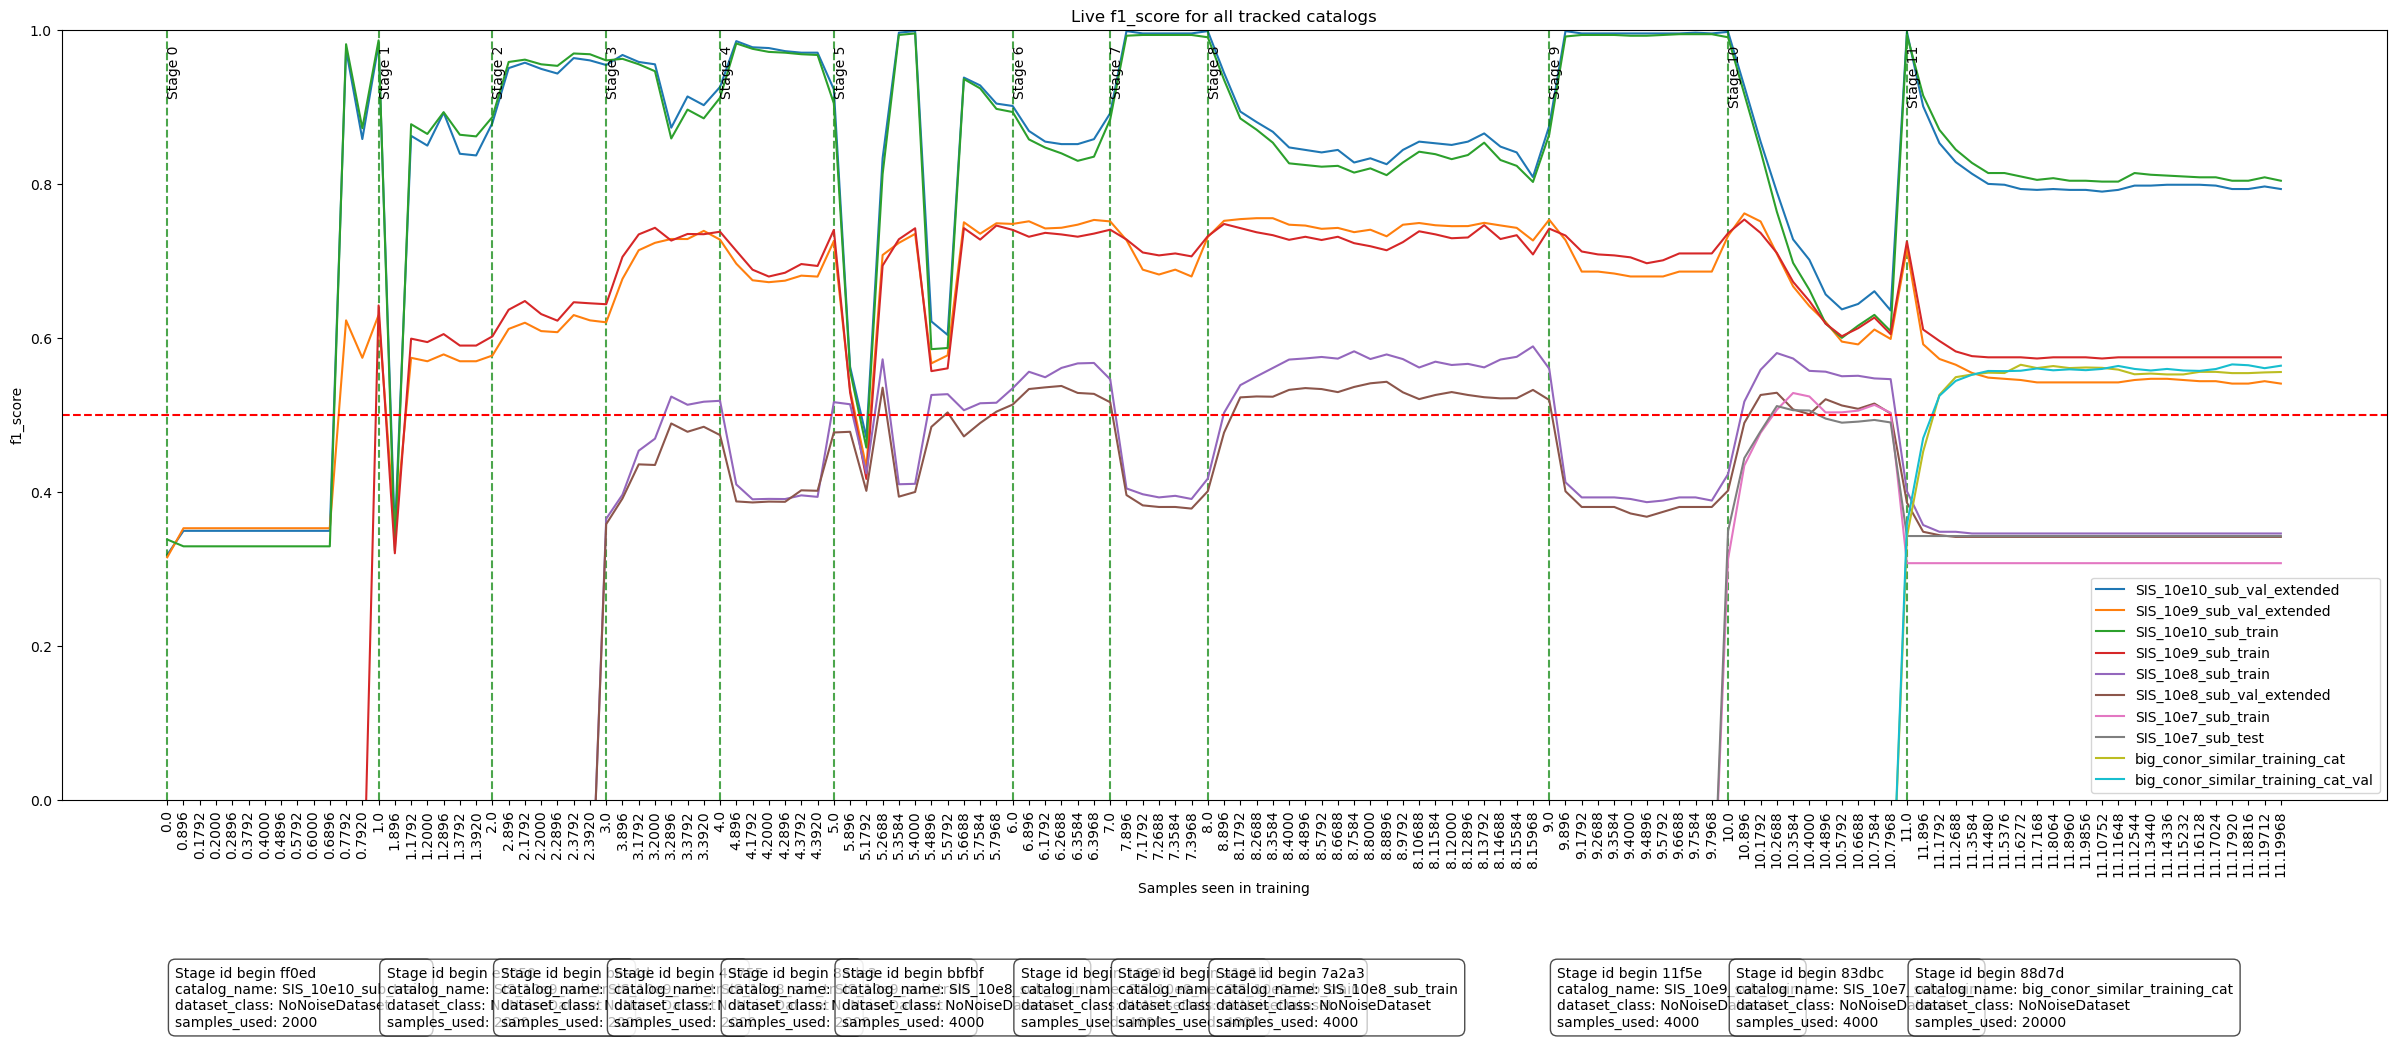

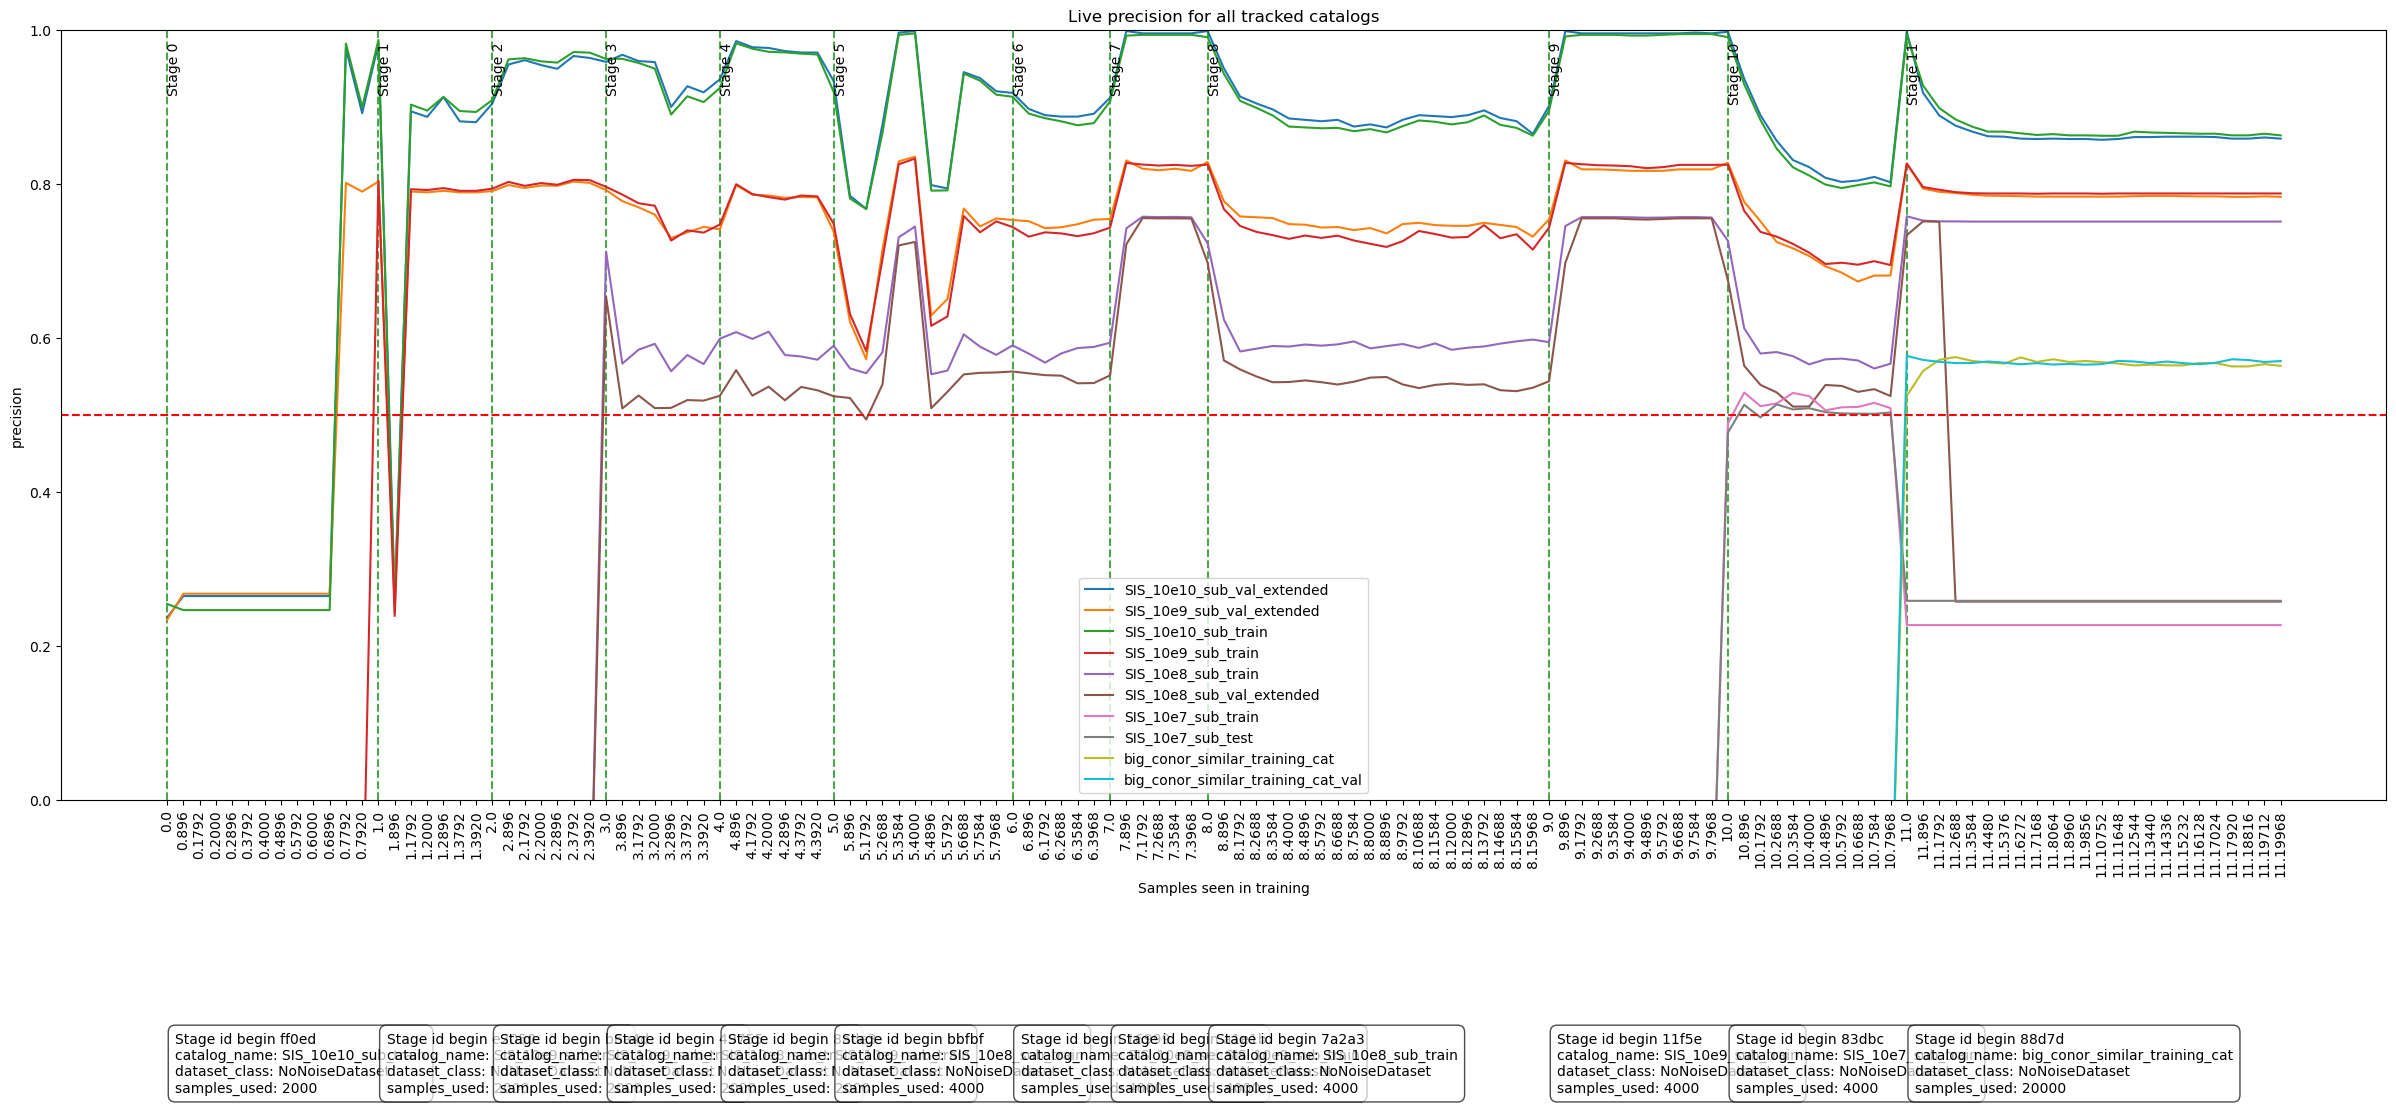

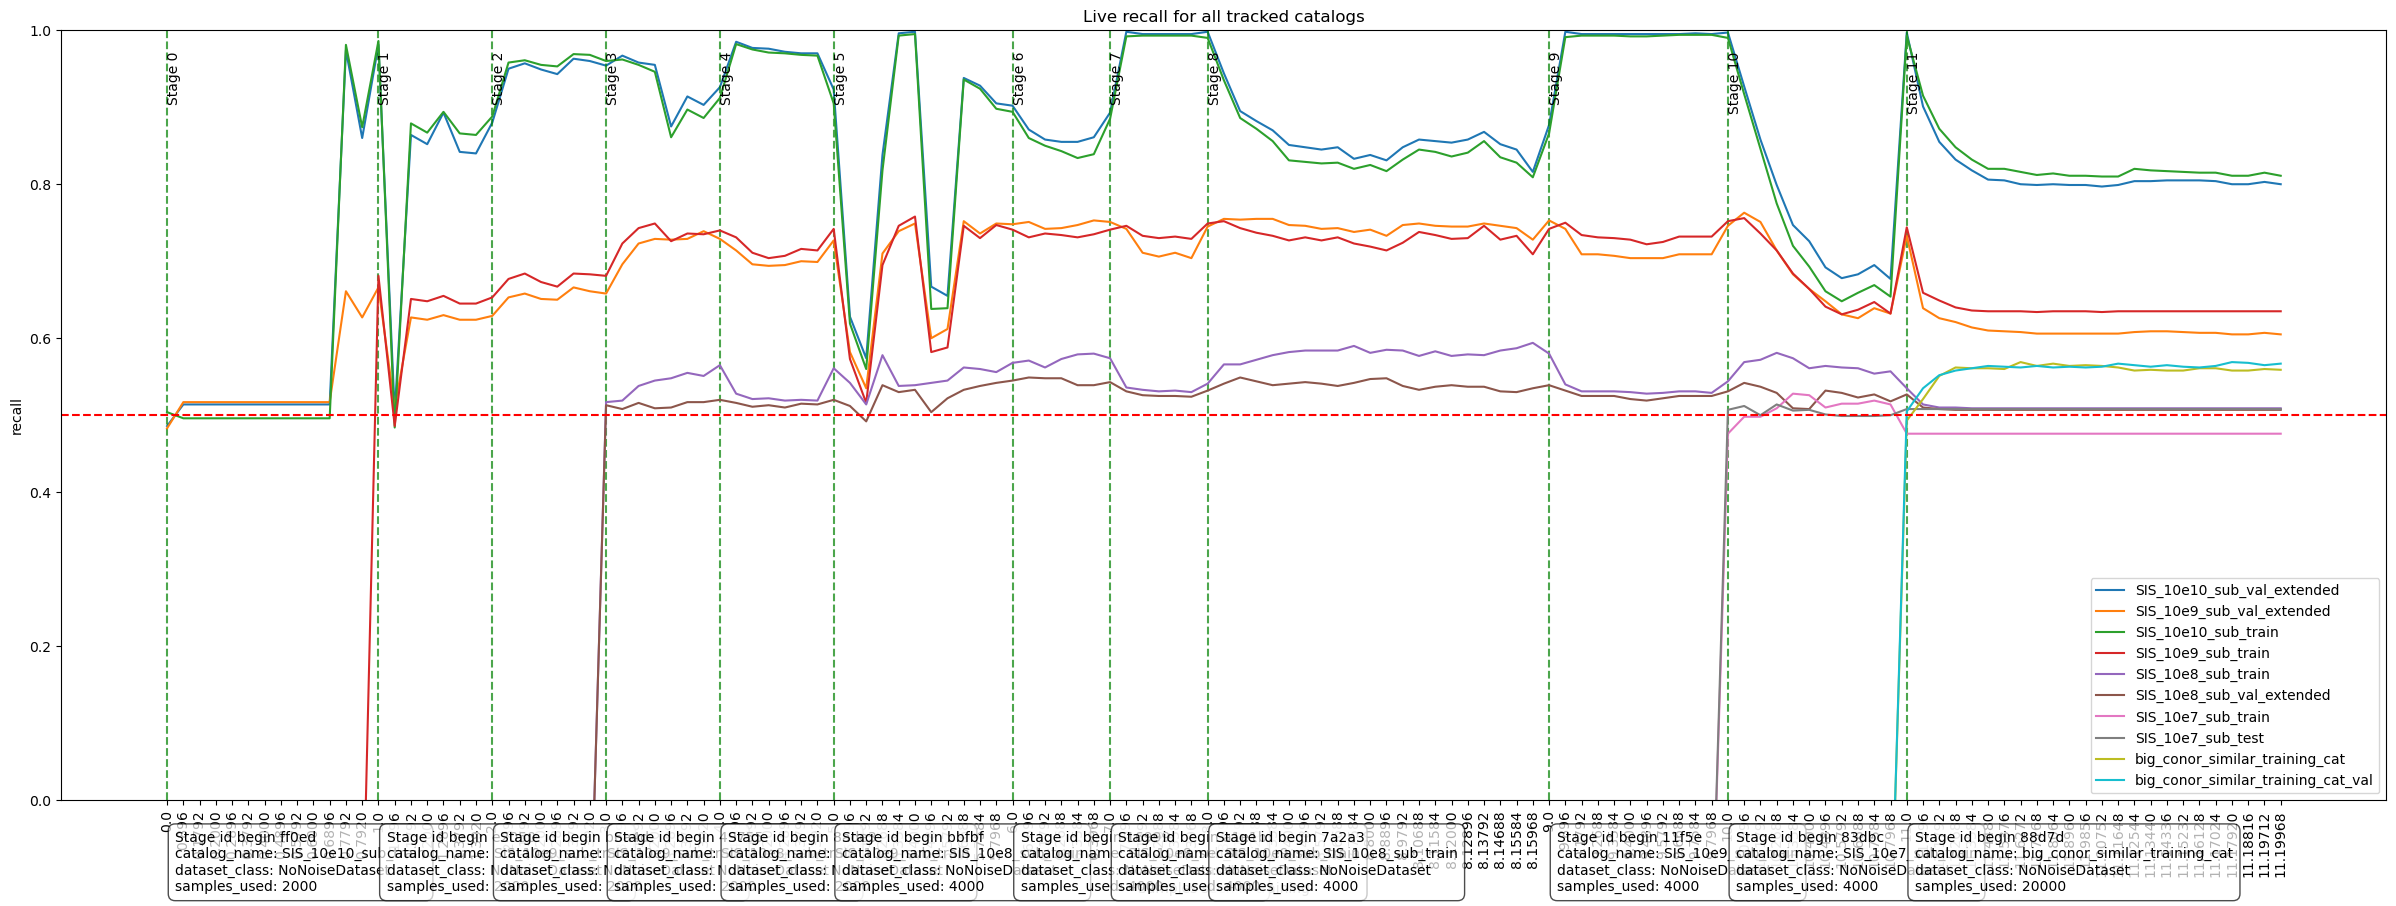

In [ ]:
from substructure_classifier.substructure_classifier_development import SubstructureClassifier

my_classifier=SubstructureClassifier(classifier_name="SimpleResnet3")
my_classifier._plot_concatenated_data()